In [24]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Number of records: 4320
Date range: 2025-01-01 00:00:00 – 2025-06-29 23:00:00
Missing values:
 date      0
target    0
dtype: int64


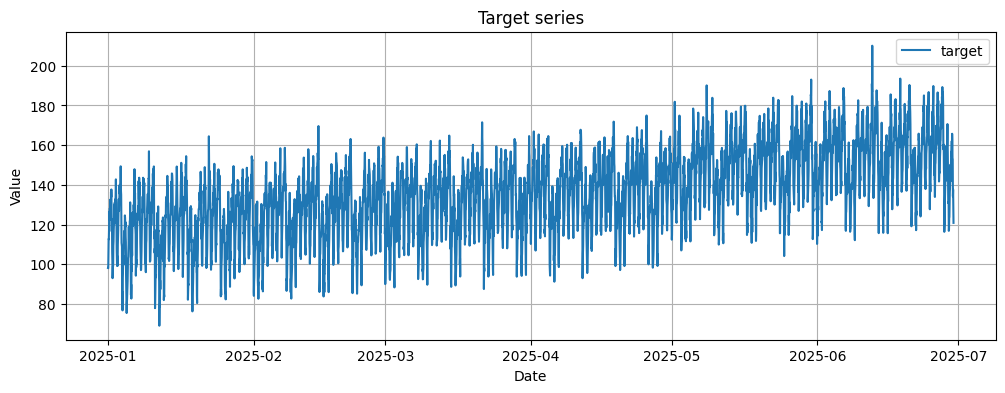

In [3]:
df = pd.read_csv("S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Number of records: {len(df)}")
print(f"Date range: {df['date'].min()} – {df['date'].max()}")
print("Missing values:\n", df.isnull().sum())

plt.figure(figsize=(12,4))
plt.plot(df['date'], df['target'], label='target')
plt.title("Target series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

Train: 2025-01-01 00:00:00 – 2025-05-06 23:00:00 | 3024 rows
Val:   2025-05-07 00:00:00 – 2025-06-02 23:00:00 | 648 rows
Test:  2025-06-03 00:00:00 – 2025-06-29 23:00:00 | 648 rows


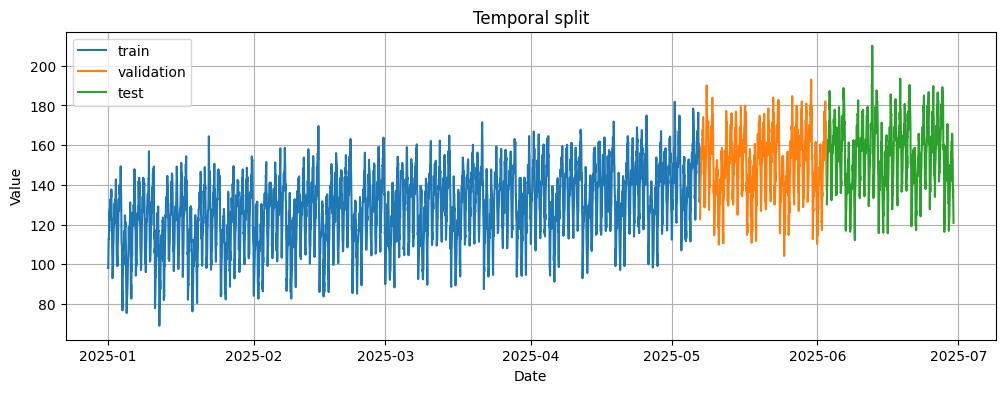

In [4]:
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15

n = len(df)
train_end = int(n * train_frac)
val_end = int(n * (train_frac + val_frac))

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train: {train_df['date'].min()} – {train_df['date'].max()} | {len(train_df)} rows")
print(f"Val:   {val_df['date'].min()} – {val_df['date'].max()} | {len(val_df)} rows")
print(f"Test:  {test_df['date'].min()} – {test_df['date'].max()} | {len(test_df)} rows")

plt.figure(figsize=(12,4))
plt.plot(train_df['date'], train_df['target'], label='train')
plt.plot(val_df['date'],   val_df['target'],   label='validation')
plt.plot(test_df['date'],  test_df['target'],  label='test')
plt.title("Temporal split")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/series_split.png")
plt.show()

In [5]:
def add_calendar_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    return df

def add_lag_features(df, target='target', lags=[1,7,14]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df[target].shift(lag)
    return df

def add_rolling_features(df, target='target', windows=[7,14]):
    df = df.copy()
    for w in windows:
        df[f'rolling_mean_{w}'] = df[target].shift(1).rolling(window=w).mean()
        df[f'rolling_std_{w}']  = df[target].shift(1).rolling(window=w).std()
    return df

feature_df = df.copy()
feature_df = add_calendar_features(feature_df)
feature_df = add_lag_features(feature_df, lags=[1,7,14])
feature_df = add_rolling_features(feature_df, windows=[7,14])
feature_df = feature_df.dropna().reset_index(drop=True)

# Применяем тот же split
train_feat = feature_df[feature_df['date'] <= train_df['date'].max()].copy()
val_feat   = feature_df[(feature_df['date'] > train_df['date'].max()) & (feature_df['date'] <= val_df['date'].max())].copy()
test_feat  = feature_df[feature_df['date'] > val_df['date'].max()].copy()

feature_cols = [c for c in feature_df.columns if c not in ['date', 'target']]
X_train = train_feat[feature_cols]
y_train = train_feat['target']
X_val   = val_feat[feature_cols]
y_val   = val_feat['target']
X_test  = test_feat[feature_cols]
y_test  = test_feat['target']

# Масштабирование для Ridge
scaler_ridge = StandardScaler()
X_train_scaled = scaler_ridge.fit_transform(X_train)
X_val_scaled   = scaler_ridge.transform(X_val)
X_test_scaled  = scaler_ridge.transform(X_test)

In [6]:
val_pred_naive = val_df['target'].shift(1).dropna().values
y_val_naive = val_df['target'].iloc[1:].values
mae_naive = mean_absolute_error(y_val_naive, val_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val_naive, val_pred_naive))
mape_naive = np.mean(np.abs((y_val_naive - val_pred_naive) / np.maximum(np.abs(y_val_naive), 1e-8))) * 100
print(f"B1 (naive) val MAE={mae_naive:.4f}, RMSE={rmse_naive:.4f}, MAPE={mape_naive:.2f}%")

B1 (naive) val MAE=6.4385, RMSE=8.1969, MAPE=4.39%


In [7]:
val_pred_ma7 = val_df['target'].rolling(7).mean().shift(1).dropna().values
y_val_ma7 = val_df['target'].iloc[7:].values
mae_ma7 = mean_absolute_error(y_val_ma7, val_pred_ma7)
rmse_ma7 = np.sqrt(mean_squared_error(y_val_ma7, val_pred_ma7))
mape_ma7 = np.mean(np.abs((y_val_ma7 - val_pred_ma7) / np.maximum(np.abs(y_val_ma7), 1e-8))) * 100
print(f"B2 (MA7) val MAE={mae_ma7:.4f}, RMSE={rmse_ma7:.4f}, MAPE={mape_ma7:.2f}%")

B2 (MA7) val MAE=12.7115, RMSE=15.2354, MAPE=8.82%


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
val_pred_ridge = ridge.predict(X_val_scaled)
mae_ridge = mean_absolute_error(y_val, val_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, val_pred_ridge))
mape_ridge = np.mean(np.abs((y_val - val_pred_ridge) / np.maximum(np.abs(y_val), 1e-8))) * 100
print(f"B3 (Ridge) val MAE={mae_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAPE={mape_ridge:.2f}%")

B3 (Ridge) val MAE=6.0282, RMSE=7.5043, MAPE=4.01%


In [9]:
# Скалер для таргета
scaler_target = StandardScaler()
# Обучаем только на train
train_target_scaled = scaler_target.fit_transform(train_df[['target']]).flatten()
val_target_scaled   = scaler_target.transform(val_df[['target']]).flatten()
test_target_scaled  = scaler_target.transform(test_df[['target']]).flatten()

In [10]:
class SeqDataset(Dataset):
    def __init__(self, data, window=24, horizon=1):
        # data: 1D array (numpy or list)
        self.data = torch.tensor(data, dtype=torch.float32).view(-1, 1)
        self.window = window
        self.horizon = horizon
    def __len__(self):
        return len(self.data) - self.window - self.horizon + 1
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window]
        y = self.data[idx+self.window+self.horizon-1].squeeze()
        return x, y

WINDOW = 24
train_seq = SeqDataset(train_target_scaled, window=WINDOW)
val_seq   = SeqDataset(val_target_scaled,   window=WINDOW)
test_seq  = SeqDataset(test_target_scaled,  window=WINDOW)

train_loader = DataLoader(train_seq, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_seq,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_seq,  batch_size=64, shuffle=False)

In [11]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1]          # (batch, hidden)
        return self.fc(last_hidden).squeeze(-1)  # (batch,)

model = GRUForecaster().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    total_loss = 0.0
    y_true_scaled, y_pred_scaled = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
            y_true_scaled.extend(yb.cpu().numpy())
            y_pred_scaled.extend(pred.cpu().numpy())
    # Обратное масштабирование, если scaler передан
    if scaler is not None:
        y_true = scaler.inverse_transform(np.array(y_true_scaled).reshape(-1,1)).flatten()
        y_pred = scaler.inverse_transform(np.array(y_pred_scaled).reshape(-1,1)).flatten()
    else:
        y_true = np.array(y_true_scaled)
        y_pred = np.array(y_pred_scaled)
    metrics = evaluate_regression(y_true, y_pred)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics, y_true, y_pred

In [13]:
num_epochs = 50
best_val_mae = float('inf')
best_state = None
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

for epoch in range(1, num_epochs+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device, scaler=scaler_target)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_mae'].append(val_metrics['MAE'])
    if val_metrics['MAE'] < best_val_mae:
        best_val_mae = val_metrics['MAE']
        best_state = model.state_dict()
    print(f"Epoch {epoch:2d} | train_loss={train_loss:.4f} | val_MAE={val_metrics['MAE']:.4f}")

Epoch  1 | train_loss=0.6967 | val_MAE=13.7468
Epoch  2 | train_loss=0.3326 | val_MAE=9.6867
Epoch  3 | train_loss=0.1861 | val_MAE=7.3860
Epoch  4 | train_loss=0.1604 | val_MAE=6.8133
Epoch  5 | train_loss=0.1544 | val_MAE=7.3374
Epoch  6 | train_loss=0.1507 | val_MAE=6.8535
Epoch  7 | train_loss=0.1481 | val_MAE=6.6937
Epoch  8 | train_loss=0.1461 | val_MAE=6.3912
Epoch  9 | train_loss=0.1450 | val_MAE=6.9630
Epoch 10 | train_loss=0.1426 | val_MAE=6.7265
Epoch 11 | train_loss=0.1419 | val_MAE=6.4062
Epoch 12 | train_loss=0.1396 | val_MAE=6.7110
Epoch 13 | train_loss=0.1356 | val_MAE=6.8239
Epoch 14 | train_loss=0.1300 | val_MAE=6.6043
Epoch 15 | train_loss=0.1201 | val_MAE=6.9779
Epoch 16 | train_loss=0.1096 | val_MAE=7.5299
Epoch 17 | train_loss=0.1073 | val_MAE=6.6579
Epoch 18 | train_loss=0.1059 | val_MAE=6.7921
Epoch 19 | train_loss=0.1040 | val_MAE=6.6187
Epoch 20 | train_loss=0.1037 | val_MAE=6.4027
Epoch 21 | train_loss=0.1035 | val_MAE=6.1509
Epoch 22 | train_loss=0.1022 | va

In [14]:
torch.save(best_state, "artifacts/best_gru.pt")
config = {
    'input_size': 1,
    'hidden_size': 32,
    'num_layers': 1,
    'dropout': 0.0,
    'window_size': WINDOW,
    'batch_size': 64,
    'learning_rate': 0.001,
    'epochs_trained': len(history['train_loss']),
    'seed': SEED,
    'scaler': 'StandardScaler'
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=2)

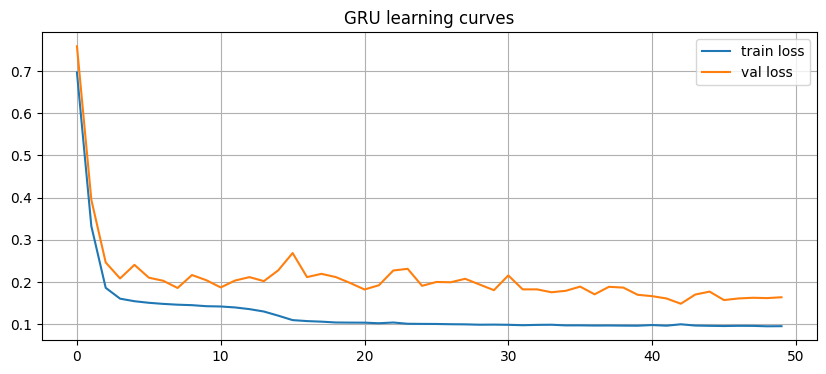

In [15]:
plt.figure(figsize=(10,4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend()
plt.title("GRU learning curves")
plt.grid(True)
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

In [16]:
model.load_state_dict(best_state)
test_metrics, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device, scaler=scaler_target)
print(f"Test metrics: MAE={test_metrics['MAE']:.4f}, RMSE={test_metrics['RMSE']:.4f}, MAPE={test_metrics['MAPE']:.2f}%")

Test metrics: MAE=6.8622, RMSE=8.8138, MAPE=4.42%


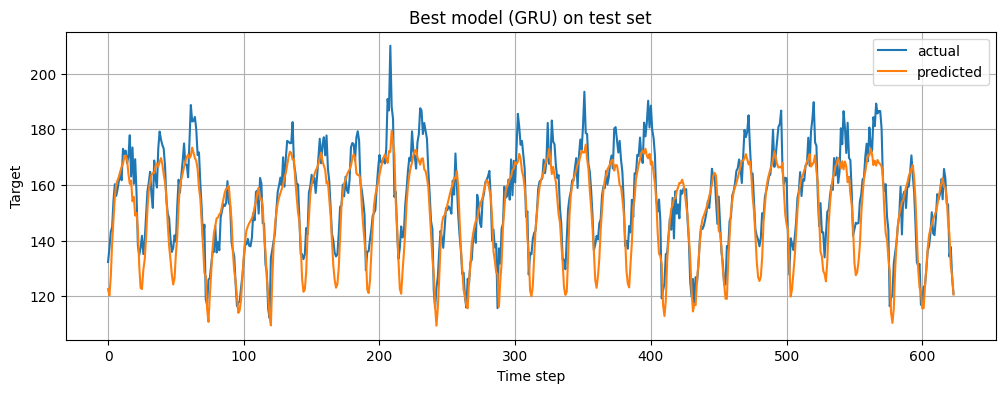

In [17]:
plt.figure(figsize=(12,4))
plt.plot(y_true_test, label='actual')
plt.plot(y_pred_test, label='predicted')
plt.title("Best model (GRU) on test set")
plt.xlabel("Time step")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

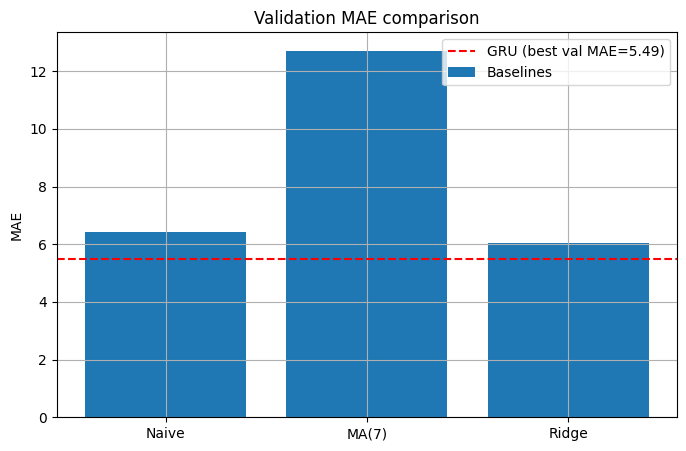

In [18]:
baseline_mae = [mae_naive, mae_ma7, mae_ridge]
names = ['Naive', 'MA(7)', 'Ridge']
plt.figure(figsize=(8,5))
plt.bar(names, baseline_mae, label='Baselines')
plt.axhline(y=best_val_mae, color='r', linestyle='--', label=f'GRU (best val MAE={best_val_mae:.2f})')
plt.title("Validation MAE comparison")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

In [19]:
import csv
results = [
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv',
     'seed': SEED, 'split_summary': '70/15/15', 'window_size': None, 'horizon': 1,
     'model_summary': 'naive-last', 'features_summary': 'none', 'scaler': 'none',
     'optimizer': 'none', 'lr': None, 'epochs_trained': None,
     'best_val_mae': mae_naive, 'best_val_rmse': rmse_naive, 'best_val_mape': mape_naive,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv',
     'seed': SEED, 'split_summary': '70/15/15', 'window_size': None, 'horizon': 1,
     'model_summary': 'moving_avg_7', 'features_summary': 'none', 'scaler': 'none',
     'optimizer': 'none', 'lr': None, 'epochs_trained': None,
     'best_val_mae': mae_ma7, 'best_val_rmse': rmse_ma7, 'best_val_mape': mape_ma7,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv',
     'seed': SEED, 'split_summary': '70/15/15', 'window_size': None, 'horizon': 1,
     'model_summary': 'Ridge', 'features_summary': 'lags_1_7_14,roll_7_14,calend', 'scaler': 'StandardScaler',
     'optimizer': 'none', 'lr': None, 'epochs_trained': None,
     'best_val_mae': mae_ridge, 'best_val_rmse': rmse_ridge, 'best_val_mape': mape_ridge,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': ''},
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv',
     'seed': SEED, 'split_summary': '70/15/15', 'window_size': WINDOW, 'horizon': 1,
     'model_summary': 'GRU', 'features_summary': 'window_24', 'scaler': 'StandardScaler',
     'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': len(history['train_loss']),
     'best_val_mae': best_val_mae, 'best_val_rmse': None, 'best_val_mape': None,
     'test_mae': test_metrics['MAE'], 'test_rmse': test_metrics['RMSE'], 'test_mape': test_metrics['MAPE'],
     'notes': 'hidden_size=32, num_layers=1, window=24'}
]

with open("artifacts/runs.csv", "w", newline='') as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)